# 15 매매전략

## 15.1 단순 이동평균

### 15.1.1 데이터 임포트

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

In [3]:
raw = pd.read_csv('../source/tr_eikon_eod_data.csv', index_col=0, parse_dates=True).dropna()

In [4]:
raw.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2138 entries, 2010-01-04 to 2018-06-29
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL.O  2138 non-null   float64
 1   MSFT.O  2138 non-null   float64
 2   INTC.O  2138 non-null   float64
 3   AMZN.O  2138 non-null   float64
 4   GS.N    2138 non-null   float64
 5   SPY     2138 non-null   float64
 6   .SPX    2138 non-null   float64
 7   .VIX    2138 non-null   float64
 8   EUR=    2138 non-null   float64
 9   XAU=    2138 non-null   float64
 10  GDX     2138 non-null   float64
 11  GLD     2138 non-null   float64
dtypes: float64(12)
memory usage: 217.1 KB


In [5]:
symbol = 'AAPL.O'

In [6]:
data = pd.DataFrame(raw[symbol]).dropna()

### 15.1.2 매매 전략

In [7]:
SMA1 = 42
SMA2 = 252

In [8]:
data['SMA1'] = data[symbol].rolling(SMA1).mean() # 단기 이동평균선 계산
data['SMA2'] = data[symbol].rolling(SMA2).mean() # 장기 이동평균선 계산

<Axes: xlabel='Date'>

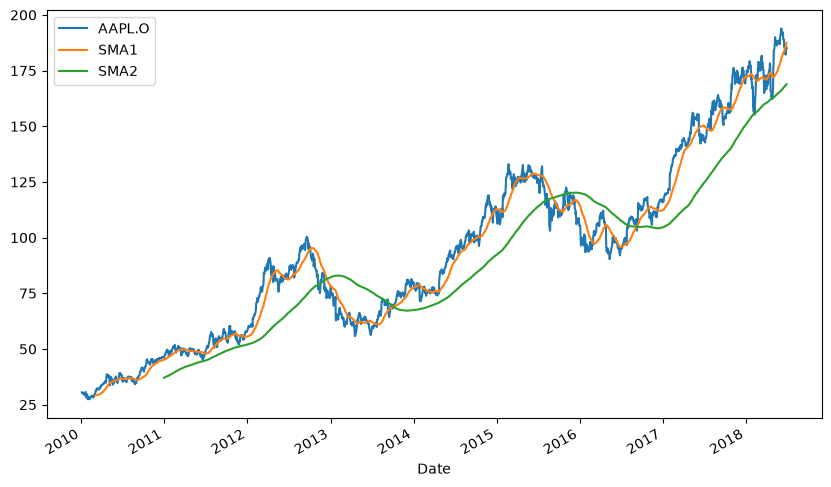

In [9]:
data.plot(figsize=(10, 6))

- 단기 이동평균선이 장기 이동평균선 위에 있으면 매수 포지션 (= +1)

- 장기 이동평균선이 단기 이동평균선 위에 있으면 매도 포지션 (= -1), 혹은 중립 포지션

In [10]:
data.dropna(inplace=True)

In [11]:
data['Position'] = np.where(data['SMA1'] > data['SMA2'], 1, -1)

In [12]:
data.tail()

,AAPL.O,SMA1,SMA2,Position
Date,,,,
2018-06-25,182.17,185.606190,168.265556,1
2018-06-26,184.43,186.087381,168.418770,1
2018-06-27,184.16,186.607381,168.579206,1
2018-06-28,185.50,187.089286,168.736627,1
2018-06-29,185.11,187.470476,168.901032,1


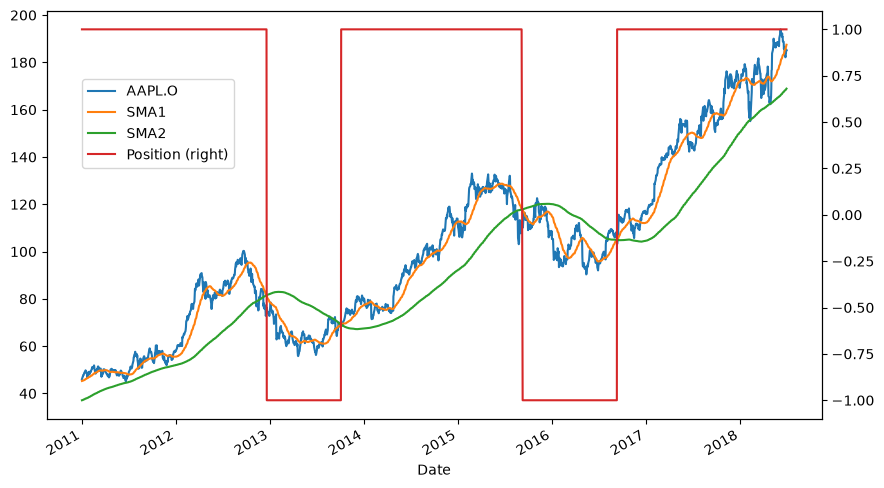

In [13]:
ax = data.plot(secondary_y='Position', figsize=(10, 6))
ax.get_legend().set_bbox_to_anchor((0.25, 0.85))

알고리즘 트레이딩 전략을 구현하면 단순히 애플 주식을 전 기간 동안 매수하여 들고 있던 것보다 더 나은 성과를 보인다는 것.

성과의 차이는 두 개의 매도 구간 때문.

### 15.1.3 벡터화된 백테스팅

**벡터화된 백테스팅 방법:**

1. 로그 수익률을 계산

2. +1 또는 -1로 나타낸 포지션을 로그 수익률에 곱함 (로그 수익률이 양수인 기간은 매수 수익, 로그 수익률이 음수인 구간은 매도 수익)

3. 원래의 애플 주가와 알고리즘 트레이딩 수익률을 모두 더한 후 지수함수를 적용

In [14]:
data['Returns'] = np.log(data[symbol]).diff() # 애플 주가의 로그 수익률 계산

In [15]:
data['Strategy'] = data['Returns'] * data['Position'].shift(1) # 포지션 값을 하루 늦추고 로그 수익률을 곱함. 하루 늦추는 것은 미래 예측을 막기 위한 것.

In [16]:
data.round(4).head()

,AAPL.O,SMA1,SMA2,Position,Returns,Strategy
Date,,,,,,
2010-12-31,46.0800,45.2810,37.1207,1,NaN,NaN
2011-01-03,47.0814,45.3497,37.1862,1,0.0215,0.0215
2011-01-04,47.3271,45.4126,37.2525,1,0.0052,0.0052
2011-01-05,47.7142,45.4661,37.3223,1,0.0081,0.0081
2011-01-06,47.6757,45.5226,37.3921,1,-0.0008,-0.0008


In [17]:
data.dropna(inplace=True)

In [18]:
np.exp(data[['Returns', 'Strategy']].sum()) # 로그 수익률의 합을 계산한 후 지수함수를 적용하여 절대 성과 계산

Returns     4.017148
Strategy    5.811299
dtype: float64

In [19]:
data[['Returns', 'Strategy']].std() * 252 ** 0.5 # 벤치마크와 전략 투자의 연율화된 변동성 계산

Returns     0.250571
Strategy    0.250407
dtype: float64

- 알고리즘 트레이딩 전략이 벤치마크 투자나 애플주식을 그냥 들고 있는 것보다 우수하다는 것을 보임.

- 전략의 특성상 연율화된 변동성 값이 같음.

- 따라서 위험조정 측면에서 보아도 벤치마크 투자보다 뛰어나다는 것을 알 수 있음.

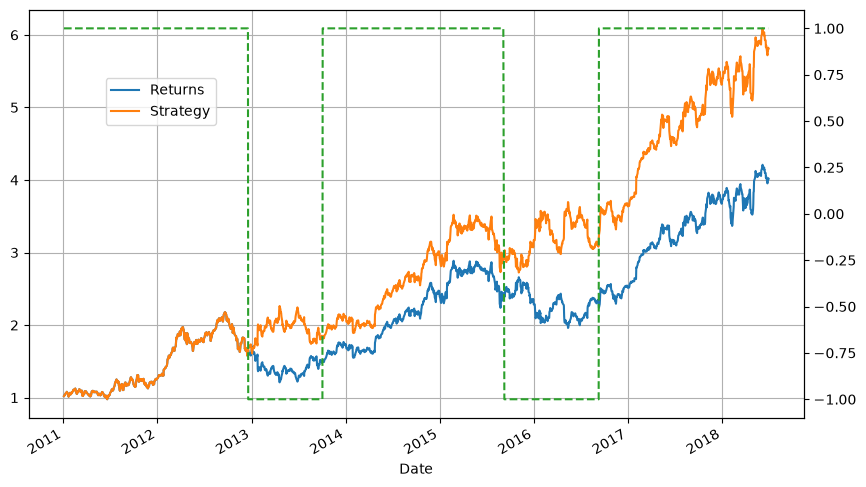

In [20]:
ax = data[['Returns', 'Strategy']].cumsum().apply(np.exp).plot(figsize=(10, 6))
data['Position'].plot(ax=ax, secondary_y='Position', style='--')
ax.get_legend().set_bbox_to_anchor((0.25, 0.85))
ax.grid()

단순화 가정: 

매매비용(수수료, 매수-매도 스프레드, 대여 수수료 등)이 포함되어 있지 않음. 매매 빈도가 많지 않은 전략의 경우에는 이런 가정을 정당화할 수 있음. 

또한 모든 매매가 하루의 종가로 발생한다고 가정.

좀 더 현실적인 백테스팅 방법이나 다른 (시장 미시구조적인) 요소들을 고려한 백테스팅 방법도 있을 수 있음.

### 15.1.4 최적화

In [21]:
from itertools import product

In [22]:
sma1 = range(20, 61, 4) # SMA1 매개변수 설정
sma2 = range(180, 281, 10) # SMA2 매개변수 설정

In [23]:
results = []

for SMA1, SMA2 in product(sma1, sma2):
    data = pd.DataFrame(raw[symbol]).dropna()

    data['Returns'] = np.log(data[symbol]).diff()
    data['SMA1'] = data[symbol].rolling(SMA1).mean()
    data['SMA2'] = data[symbol].rolling(SMA2).mean()
    data.dropna(inplace=True)

    data['Position'] = np.where(data['SMA1'] > data['SMA2'], 1, -1)
    data['Strategy'] = data['Returns'] * data['Position'].shift(1)
    data.dropna(inplace=True)

    perf = np.exp(data[['Returns', 'Strategy']].sum())

    results.append({
        'SMA1': SMA1, 
        'SMA2': SMA2, 
        'MARKET': perf['Returns'], 
        'STRATEGY': perf['Strategy'], 
        'OUT': perf['Strategy'] - perf['Returns']
    })

results = pd.DataFrame(results)

In [24]:
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SMA1      121 non-null    int64  
 1   SMA2      121 non-null    int64  
 2   MARKET    121 non-null    float64
 3   STRATEGY  121 non-null    float64
 4   OUT       121 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 4.9 KB


In [25]:
results.sort_values('OUT', ascending=False).head(7)

,SMA1,SMA2,MARKET,STRATEGY,OUT
56,40,190,4.650342,7.175173,2.524831
39,32,240,4.045619,6.558690,2.513071
59,40,220,4.220272,6.544266,2.323994
46,36,200,4.074753,6.389627,2.314874
55,40,180,4.574979,6.857989,2.283010
70,44,220,4.220272,6.469843,2.249571
101,56,200,4.074753,6.319524,2.244772


이런 단순 최적화 방법을 따르면 최적의 매개변수는 `SMA1=40, SMA2=190`, 성과는 벤치마크 투자를 약 250%p 앞섬.

하지만 사용된 데이터에 심하게 의존하는 값이므로 과최적화(overfitting)되어 있을 가능성이 높음.

좀 더 엄밀한 방법은 학습용 데이터를 사용하여 최적화하고 검증용 데이터를 사용하여 검사하는 방법.

## 15.2 랜덤워크 가설

In [26]:
symbol = '.SPX'

In [27]:
data = pd.DataFrame(raw[symbol])

In [28]:
lags = 5
cols = []
for lag in range(1, lags + 1):
    col = f'lag_{lag}'
    data[col] = data[symbol].shift(lag)
    cols.append(col)

In [29]:
data.head()

,.SPX,lag_1,lag_2,lag_3,lag_4,lag_5
Date,,,,,,
2010-01-04,1132.99,NaN,NaN,NaN,NaN,NaN
2010-01-05,1136.52,1132.99,NaN,NaN,NaN,NaN
2010-01-06,1137.14,1136.52,1132.99,NaN,NaN,NaN
2010-01-07,1141.69,1137.14,1136.52,1132.99,NaN,NaN
2010-01-08,1144.98,1141.69,1137.14,1136.52,1132.99,NaN


In [30]:
data.dropna(inplace=True)

In [31]:
reg = np.linalg.lstsq(data[cols], data[symbol], rcond=-1)[0]

In [32]:
reg.round(3)

array([ 0.961,  0.009,  0.034, -0.017,  0.014])

<BarContainer object of 5 artists>

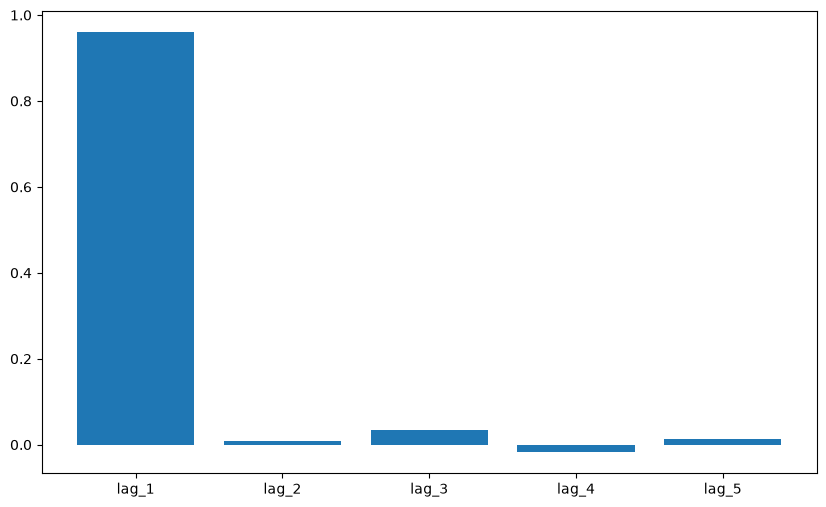

In [33]:
plt.figure(figsize=(10, 6))
plt.bar(cols, reg)

예측 역할을 하는 것은 lag_1뿐.

예측선은 원래의 데이터를 하루 늦춘 것에 지나지 않음.

In [34]:
data['Prediction'] = data[cols] @ reg

<Axes: xlabel='Date'>

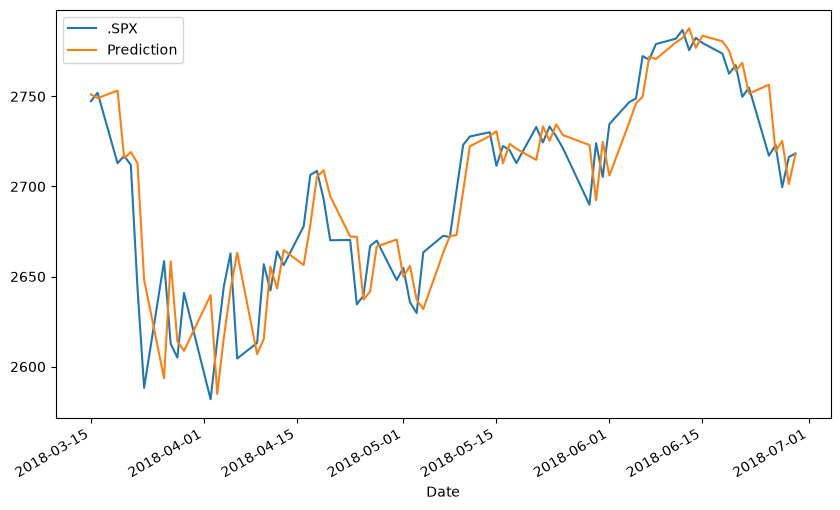

In [35]:
data[[symbol, 'Prediction']].iloc[-75:].plot(figsize=(10, 6))

랜덤워크 가설과 효율적 시장 가설을 모두 지지. 랜덤워크 가설과 효율적 시장 가설은 방대한 실증적 지지를 받고 있는 금융 이론.

모든 알고리즘 트레이딩 전략은 랜덤워크 가설이 일반적으로 적용되지 않는다는 것을 증명하여 스스로의 가치를 보여야 함. 

## 15.3 선형 회귀분석

과거의 로그 수익률을 기반으로 시장의 방향성을 예측하는 데 선형 회귀분석을 적용. 

시계열 상의 하루 전 로그 수익률, 이틀 전 로그 수익률.

로그 수익률은 가격과 달리 정상(stationary) 상태이므로 통계나 머신러닝 알고리즘을 적용할 수 있음.

지연 수익률: 

- 과거의 수익률로 미래 수익률을 예측할 수 있다는 점.

- 평균회귀: ex) 이틀 연속 하락하면 다음 날은 상승하는 패턴

- 모멘텀, 추세: 계속하여 하락하는 패턴

회귀분석 기술을 응용하면 이런 추론을 정량화할 수 있음.

### 15.3.1 데이터

In [36]:
raw

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-04,30.572827,30.950,20.88,133.90,173.08,113.33,1132.99,20.04,1.4411,1120.00,47.71,109.80
2010-01-05,30.625684,30.960,20.87,134.69,176.14,113.63,1136.52,19.35,1.4368,1118.65,48.17,109.70
2010-01-06,30.138541,30.770,20.80,132.25,174.26,113.71,1137.14,19.16,1.4412,1138.50,49.34,111.51
2010-01-07,30.082827,30.452,20.60,130.00,177.67,114.19,1141.69,19.06,1.4318,1131.90,49.10,110.82
2010-01-08,30.282827,30.660,20.83,133.52,174.31,114.57,1144.98,18.13,1.4412,1136.10,49.84,111.37
...,...,...,...,...,...,...,...,...,...,...,...,...
2018-06-25,182.170000,98.390,50.71,1663.15,221.54,271.00,2717.07,17.33,1.1702,1265.00,22.01,119.89
2018-06-26,184.430000,99.080,49.67,1691.09,221.58,271.60,2723.06,15.92,1.1645,1258.64,21.95,119.26
2018-06-27,184.160000,97.540,48.76,1660.51,220.18,269.35,2699.63,17.91,1.1552,1251.62,21.81,118.58


In [37]:
raw.columns

Index(['AAPL.O', 'MSFT.O', 'INTC.O', 'AMZN.O', 'GS.N', 'SPY', '.SPX', '.VIX',
       'EUR=', 'XAU=', 'GDX', 'GLD'],
      dtype='str')

In [38]:
symbol = 'EUR='

In [39]:
data = pd.DataFrame(raw[symbol])

In [40]:
data['returns'] = np.log(data[symbol]).diff()

In [41]:
data.dropna(inplace=True)

In [42]:
data['direction'] = np.sign(data['returns']).astype(int)

In [43]:
data.head()

,EUR=,returns,direction
Date,,,
2010-01-05,1.4368,-0.002988,-1
2010-01-06,1.4412,0.003058,1
2010-01-07,1.4318,-0.006544,-1
2010-01-08,1.4412,0.006544,1
2010-01-11,1.4513,0.006984,1


<Axes: >

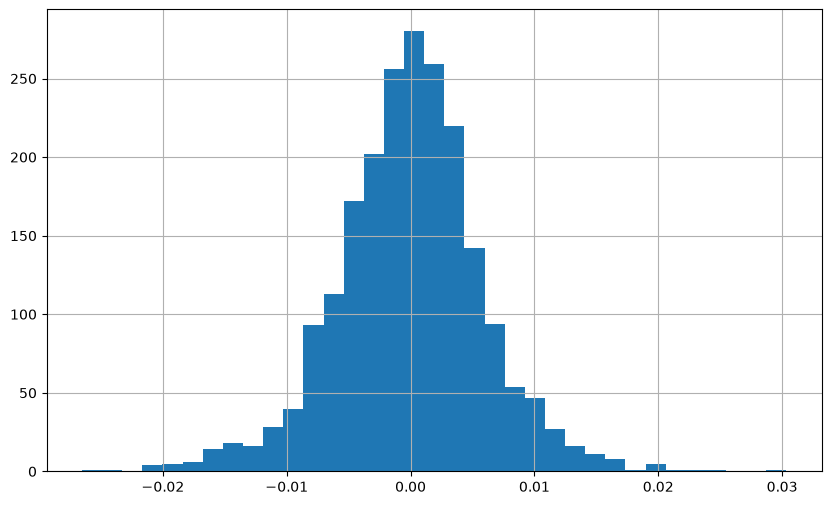

In [44]:
data['returns'].hist(bins=35, figsize=(10, 6))

In [45]:
lags = 2

In [46]:
def create_lags(data):
    global cols
    cols = []
    for lag in range(1, lags + 1):
        col = f'lag_{lag}'
        data[col] = data['returns'].shift(lag)
        cols.append(col)

In [47]:
create_lags(data)

In [48]:
data.head()

,EUR=,returns,direction,lag_1,lag_2
Date,,,,,
2010-01-05,1.4368,-0.002988,-1,NaN,NaN
2010-01-06,1.4412,0.003058,1,-0.002988,NaN
2010-01-07,1.4318,-0.006544,-1,0.003058,-0.002988
2010-01-08,1.4412,0.006544,1,-0.006544,0.003058
2010-01-11,1.4513,0.006984,1,0.006544,-0.006544


In [49]:
data.dropna(inplace=True)

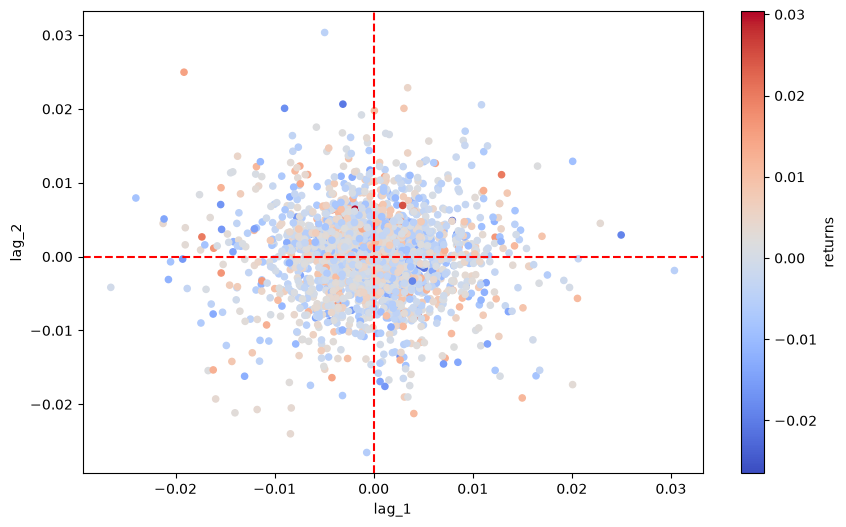

In [50]:
data.plot.scatter(x='lag_1', y='lag_2', c='returns', cmap='coolwarm', figsize=(10, 6), colorbar=True)
plt.axvline(0, c='r', ls='--')
plt.axhline(0, c='r', ls='--')

### 15.3.2 회귀분석

선형 회귀분석을 적용하여 데이터 간의 잠재적 선형 관계를 학습하고 특징 값에 기반하여 시장 움직임을 예측.

예측값을 사용하여 매매 전략을 백테스팅. 

두 가지 기본적인 방법론:

- 로그 수익률을 종속변수로 사용

- 로그 수익률의 방향을 종속변수로 사용

예측 결과인 방향을 +1 또는 -1이라는 숫자로 바꿀 수 있기 때문에 어떤 경우든 예측 결과의 형식은 달라지지 않음.

In [51]:
from sklearn.linear_model import LinearRegression

In [52]:
model = LinearRegression()

In [53]:
data['pos_ols_1'] = model.fit(data[cols], data['returns']).predict(data[cols]) # 로그 수익률을 직접 사용하여 회귀분석하는 경우

In [54]:
data['pos_ols_2'] = model.fit(data[cols], data['direction']).predict(data[cols]) # 로그 수익률의 방향을 사용하여 회귀분석하는 경우

In [55]:
data[['pos_ols_1', 'pos_ols_2']].head()

,pos_ols_1,pos_ols_2
Date,,
2010-01-07,-0.000166,-0.000086
2010-01-08,0.000017,0.040404
2010-01-11,-0.000244,-0.011756
2010-01-12,-0.000139,-0.043398
2010-01-13,-0.000022,0.002237


In [56]:
data[['pos_ols_1', 'pos_ols_2']] = np.where(data[['pos_ols_1', 'pos_ols_2']] > 0, 1, -1) # 실숫값을 +1, -1로 변환

In [57]:
data['pos_ols_1'].value_counts()

pos_ols_1
-1    1847
 1     288
Name: count, dtype: int64

In [58]:
data['pos_ols_2'].value_counts() # 두 방법론이 다른 방향을 가리킴.

pos_ols_2
 1    1377
-1     758
Name: count, dtype: int64

In [59]:
(data['pos_ols_1'].diff() != 0).sum()

np.int64(555)

In [60]:
(data['pos_ols_2'].diff() != 0).sum() # 두 방법 모두 다수의 매매로 이어짐.

np.int64(762)

방향을 예측하는 벡터화된 백테스팅을 적용하여 매매 전략의 성과를 판단할 수 있음.

두 가지 단순화 가정:

- 거래 비용이 들지 않음.

- 학습 및 검증에 같은 데이터를 사용.

In [61]:
data['strat_ols_1'] = data['pos_ols_1'] * data['returns']

In [62]:
data['strat_ols_2'] = data['pos_ols_2'] * data['returns']

In [63]:
data[['returns', 'strat_ols_1', 'strat_ols_2']].sum().apply(np.exp)

returns        0.810644
strat_ols_1    0.942422
strat_ols_2    1.339286
dtype: float64

In [64]:
(data['direction'] == data['pos_ols_1']).value_counts()

False    1093
True     1042
Name: count, dtype: int64

In [65]:
(data['direction'] == data['pos_ols_2']).value_counts() # 바른 예측과 틀린 예측의 개수

True     1096
False    1039
Name: count, dtype: int64

<Axes: xlabel='Date'>

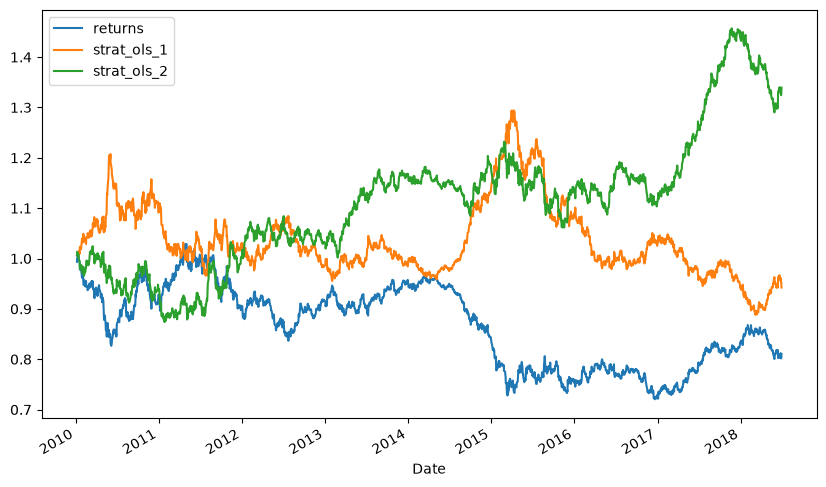

In [66]:
data[['returns', 'strat_ols_1', 'strat_ols_2']].cumsum().apply(np.exp).plot(figsize=(10, 6))

## 15.4 클러스터링

알고리즘이 시장의 움직임을 예측할 수 있는 특징값의 클러스터를 식별하는 것.

방금 사용된 두 특징값(하루 전의 로그 수익률, 이틀 전의 로그 수익률)에 k-means 알고리즘을 적용

In [67]:
from sklearn.cluster import KMeans

In [68]:
model = KMeans(n_clusters=2, random_state=0)

In [69]:
model.fit(data[cols])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",0
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](2, 2)","[[

In [70]:
data['pos_clus'] = model.predict(data[cols])

In [71]:
data['pos_clus'] = np.where(data['pos_clus'] == 1, -1, 1) # 클러스터 값으로 매수 매도 방향 선택

In [72]:
data['pos_clus'].values

array([ 1,  1,  1, ..., -1,  1,  1], shape=(2135,))

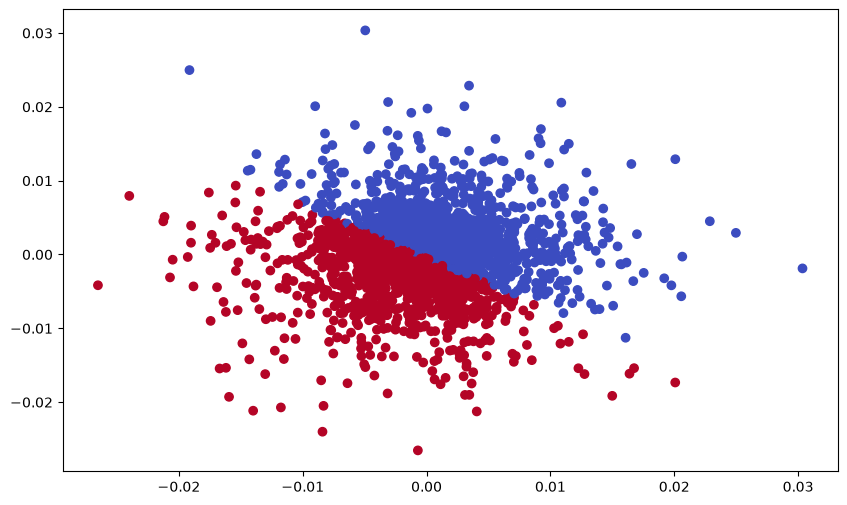

In [73]:
plt.figure(figsize=(10, 6))
plt.scatter(data[cols].iloc[:, 0], data[cols].iloc[:, 1], c=data['pos_clus'], cmap='coolwarm')

이 방법은 너무 임의적이고, 알고리즘이 추구하는 목표가 제대로 명시되지 않음.

그럼에도 성과는 패시브 벤치마크 투자보다 좋음.

In [74]:
data['strat_clus'] = data['pos_clus'] * data['returns']

In [75]:
data[['returns', 'strat_clus']].sum().apply(np.exp)

returns       0.810644
strat_clus    1.150545
dtype: float64

In [76]:
(data['direction'] == data['pos_clus']).value_counts()

True     1098
False    1037
Name: count, dtype: int64

<Axes: xlabel='Date'>

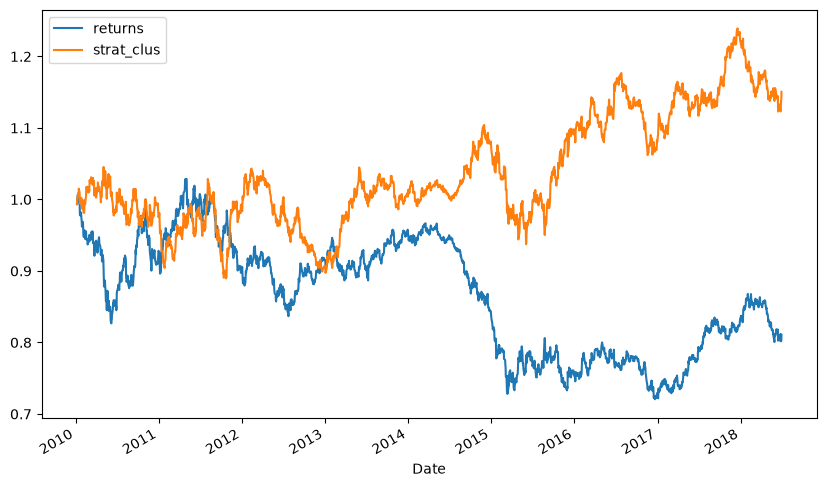

In [77]:
data[['returns', 'strat_clus']].cumsum().apply(np.exp).plot(figsize=(10, 6))

## 15.5 빈도주의 방법론

In [78]:
def create_bins(data, bins=[0]):
    global cols_bin
    cols_bin = []
    for col in cols:
        col_bin = col + '_bin'
        data[col_bin] = np.digitize(data[col], bins=bins) # 특징값을 주어진 bins 인수로 디지털화
        cols_bin.append(col_bin)

In [79]:
create_bins(data)

In [80]:
data[cols_bin + ['direction']].head() # 디지털화된 특징값과 레이블값

,lag_1_bin,lag_2_bin,direction
Date,,,
2010-01-07,1,0,-1
2010-01-08,0,1,1
2010-01-11,1,0,1
2010-01-12,1,1,-1
2010-01-13,0,1,1


In [81]:
grouped = data.groupby(cols_bin + ['direction'])
grouped.size() # 특징값 조합에 따른 시장 움직임 빈도

lag_1_bin  lag_2_bin  direction
0          0          -1           239
                       0             4
                       1           258
           1          -1           262
                       1           288
1          0          -1           272
                       0             1
                       1           278
           1          -1           278
                       0             4
                       1           251
dtype: int64

In [82]:
res = grouped['direction'].size().unstack(fill_value=0) # DataFrame 객체가 빈도 열을 가지도록 반환

In [83]:
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max] #  가장 빈도가 높은 특징값 조합

In [84]:
res.style.apply(highlight_max, axis=1)

주어진 빈도 데이터를 사용하면 세 가지 특징값 조합은 시장의 하락을 나타내고, 

다른 한 가지 특징값 조합은 시장의 상승을 나타내는 것을 알 수 있음.

In [85]:
data['pos_freq'] = np.where(data[cols_bin].sum(axis=1) == 2, -1, 1)

In [86]:
(data['direction'] == data['pos_freq']).value_counts()

True     1102
False    1033
Name: count, dtype: int64

In [87]:
data['strat_freq'] = data['pos_freq'] * data['returns']

In [88]:
data[['returns', 'strat_freq']].sum().apply(np.exp)

returns       0.810644
strat_freq    0.989513
dtype: float64

<Axes: xlabel='Date'>

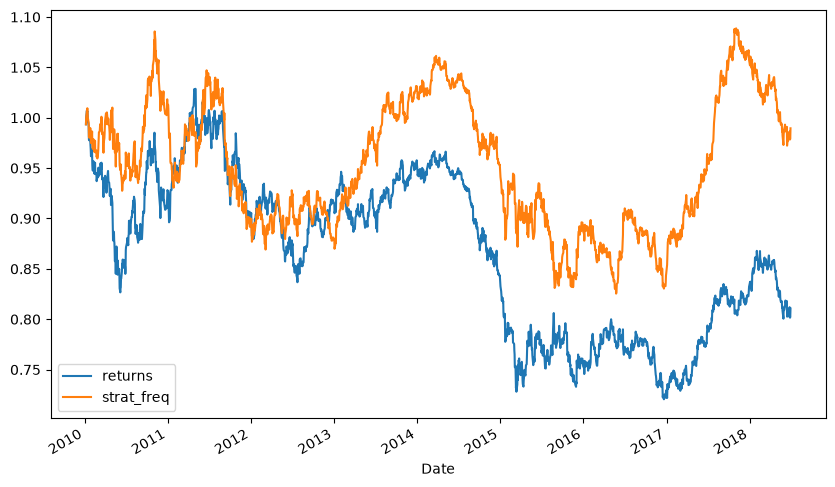

In [89]:
data[['returns', 'strat_freq']].cumsum().apply(np.exp).plot(figsize=(10, 6))

## 15.6 분류 알고리즘

### 15.6.1 두 개의 이진수 특징

In [90]:
from sklearn import linear_model
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [91]:
C = 1

In [92]:
models = {
    'log_reg': linear_model.LogisticRegression(C=C),
    'gauss_nb': GaussianNB(),
    'svm': SVC(C=C),
}

In [93]:
def fit_models(data): # 모든 모델을 학습시키는 함수
    mfit = {model: models[model].fit(data[cols_bin], data['direction']) for model in models}

In [94]:
fit_models(data)

In [95]:
def derive_positions(data): # 학습된 모델에서 포지션 정보를 받는 함수
    for model in models.keys():
        data['pos_' + model] = models[model].predict(data[cols_bin])

In [96]:
derive_positions(data)

In [97]:
def evaluate_strats(data): # 결과로 나온 매매 전략을 평가하는 함수
    global sel
    sel = []
    for model in models.keys():
        col = 'strat_' + model
        data[col] = data['pos_' + model] * data['returns']
        sel.append(col)
    sel.insert(0, 'returns')

In [98]:
evaluate_strats(data)

In [99]:
sel.insert(1, 'strat_freq')

In [100]:
data[sel].sum().apply(np.exp) # 몇몇 전략은 같은 성과를 보임.

returns           0.810644
strat_freq        0.989513
strat_log_reg     1.243322
strat_gauss_nb    1.243322
strat_svm         0.989513
dtype: float64

<Axes: xlabel='Date'>

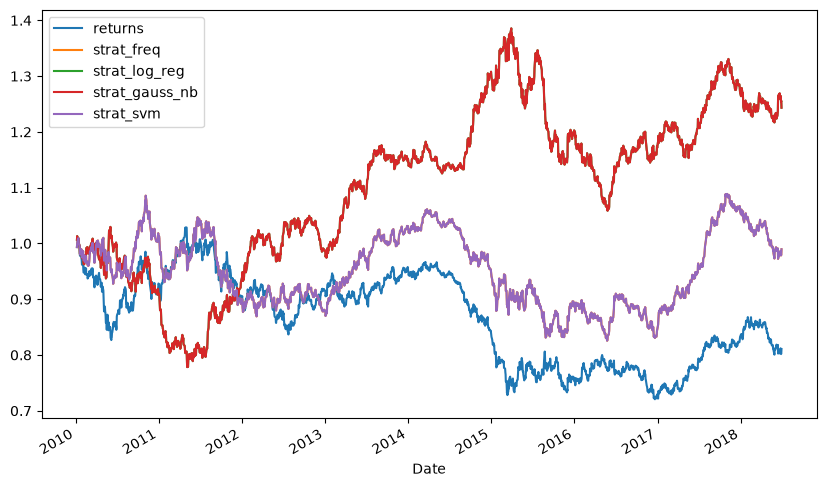

In [101]:
data[sel].cumsum().apply(np.exp).plot(figsize=(10, 6))

### 15.6.2 다섯 개의 이진수 특징

In [102]:
data = pd.DataFrame(raw[symbol])

In [103]:
data['returns'] = np.log(data).diff()

In [104]:
data['direction'] = np.sign(data['returns'])

In [105]:
lags = 5 # 다섯 개의 과거 로그 수익률을 사용
create_lags(data)
data.dropna(inplace=True)

In [106]:
create_bins(data) # 실숫값을 이진수로 변환
cols_bin

['lag_1_bin', 'lag_2_bin', 'lag_3_bin', 'lag_4_bin', 'lag_5_bin']

In [107]:
data[cols_bin].head()

,lag_1_bin,lag_2_bin,lag_3_bin,lag_4_bin,lag_5_bin
Date,,,,,
2010-01-12,1,1,0,1,0
2010-01-13,0,1,1,0,1
2010-01-14,1,0,1,1,0
2010-01-15,0,1,0,1,1
2010-01-19,0,0,1,0,1


In [108]:
data.dropna(inplace=True)

In [109]:
fit_models(data)

In [110]:
derive_positions(data)

In [111]:
evaluate_strats(data)

In [112]:
data[sel].sum().apply(np.exp)

returns           0.805002
strat_log_reg     0.971623
strat_gauss_nb    0.986420
strat_svm         2.649423
dtype: float64

<Axes: xlabel='Date'>

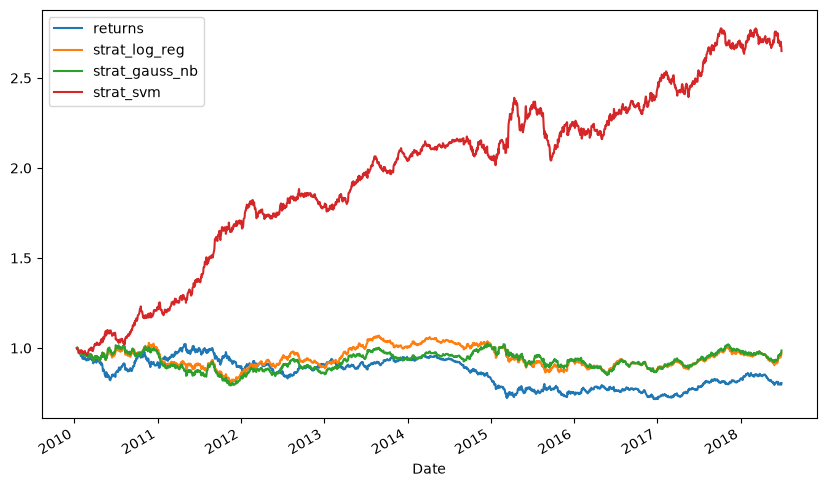

In [113]:
data[sel].cumsum().apply(np.exp).plot(figsize=(10, 6))

### 15.6.3 다섯 개의 디지털 특징

과거 로그 수익률의 1차 모멘트와 2차 모멘트를 기반으로 특징 데이터를 디지털화.

In [114]:
mu = data['returns'].mean() # 로그 수익률의 평균
v = data['returns'].std() # 로그 수익률의 표준편차

In [115]:
bins = [mu - v, mu, mu + v] # 특징값 디지털화
bins

[np.float64(-0.0060335370404186635),
 np.float64(-0.00010174015279231454),
 np.float64(0.005830056734834034)]

In [116]:
create_bins(data, bins)

In [117]:
data[cols_bin].head()

,lag_1_bin,lag_2_bin,lag_3_bin,lag_4_bin,lag_5_bin
Date,,,,,
2010-01-12,3,3,0,2,1
2010-01-13,1,3,3,0,2
2010-01-14,2,1,3,3,0
2010-01-15,1,2,1,3,3
2010-01-19,0,1,2,1,3


In [118]:
fit_models(data)

In [119]:
derive_positions(data)

In [120]:
evaluate_strats(data)

In [121]:
data[sel].sum().apply(np.exp)

returns           0.805002
strat_log_reg     1.431120
strat_gauss_nb    1.815304
strat_svm         7.165290
dtype: float64

<Axes: xlabel='Date'>

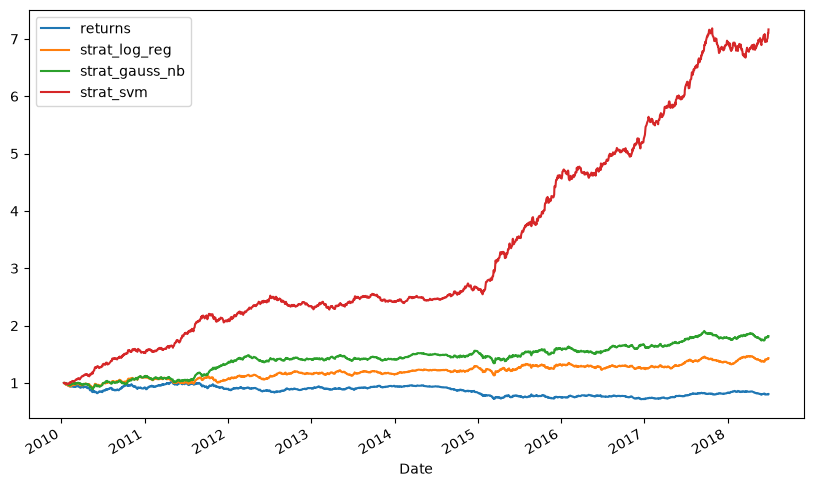

In [122]:
data[sel].cumsum().apply(np.exp).plot(figsize=(10, 6))

특징값의 유형

- 이번 장에서는 과거의 수익률을 이진화하거나 디지털화하여 특징값으로 사용. 금융 시계열 자체에서 뽑을 수 있기 때문에 편의상 사용한 것.

- 실제 응용에서는 다양한 데이터 소스를 사용하여 특징 데이터를 뽑음. 거시경제지표, 회사의 금융지표, 뉴스 기다 등 다른 시계열 데이터나 통계치가 사용될 수 있음.

### 15.6.4 연속적 학습-검증 분리

분류 알고리즘의 성능을 제대로 평가하기 위해 연속적 학습-검증 분리(sequential train-test split)를 구현.

시뮬레이션 시에도 특정 시점까지의 데이터만 사용하여 머신러닝 알고리즘을 학습하는 것.

실제 매매에서 알고리즘은 지금까지 보지 못한 데이터를 맞닥뜨리게 되는데, 이 시점에서 알고리즘은 가치를 증명할 수 있어야 함.

In [123]:
split = int(len(data) * 0.5)

In [124]:
train = data.iloc[:split].copy()

In [125]:
fit_models(train) # 학습용 데이터를 사용하여 모든 분류 알고리즘을 학습.

In [126]:
test = data.iloc[split:].copy()

In [127]:
derive_positions(test)

In [128]:
evaluate_strats(test) # 검증용 데이터를 사용하여 모든 분류 알고리즘을 검사.

In [129]:
test[sel].sum().apply(np.exp)

returns           0.850291
strat_log_reg     0.952898
strat_gauss_nb    0.941172
strat_svm         1.020519
dtype: float64

<Axes: xlabel='Date'>

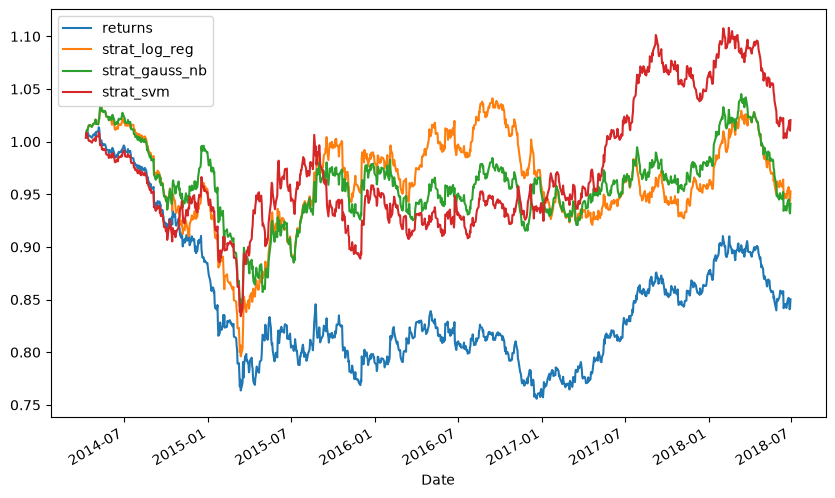

In [130]:
test[sel].cumsum().apply(np.exp).plot(figsize=(10, 6))

### 15.6.5 무작위 학습-검증 분리

시간이 지나도 과거의 패턴이 유지된다는 가정이 포함되어 있음. 따라서 학습에 사용하는 데이터와 검증에 사용하는 데이터 간에 큰 차이가 있어서는 안됨. 하지만 시간적 순서는 달라질 수 있음.

학습-검증 분리를 무작위로 할 수도 있음. 이 경우에도 학습에 사용하는 데이터와 검증에 사용하는 데이터가 다르므로 현실을 반영할 수 있음.

In [131]:
from sklearn.model_selection import train_test_split

In [132]:
train, test = train_test_split(data, test_size=0.5, shuffle=True, random_state=100)

In [133]:
train = train.copy().sort_index() # 학습용 데이터를 복사한 후 시간 순서로 다시 정렬

In [134]:
train[cols_bin].head()

,lag_1_bin,lag_2_bin,lag_3_bin,lag_4_bin,lag_5_bin
Date,,,,,
2010-01-12,3,3,0,2,1
2010-01-13,1,3,3,0,2
2010-01-14,2,1,3,3,0
2010-01-15,1,2,1,3,3
2010-01-20,1,0,1,2,1


In [135]:
test = test.copy().sort_index() # 검증용 데이터를 복사한 후 시간 순서로 다시 정렬

In [136]:
fit_models(train)

In [137]:
derive_positions(test)

In [138]:
evaluate_strats(test)

In [139]:
test[sel].sum().apply(np.exp)

returns           0.878078
strat_log_reg     0.801787
strat_gauss_nb    0.765009
strat_svm         0.730141
dtype: float64

<Axes: xlabel='Date'>

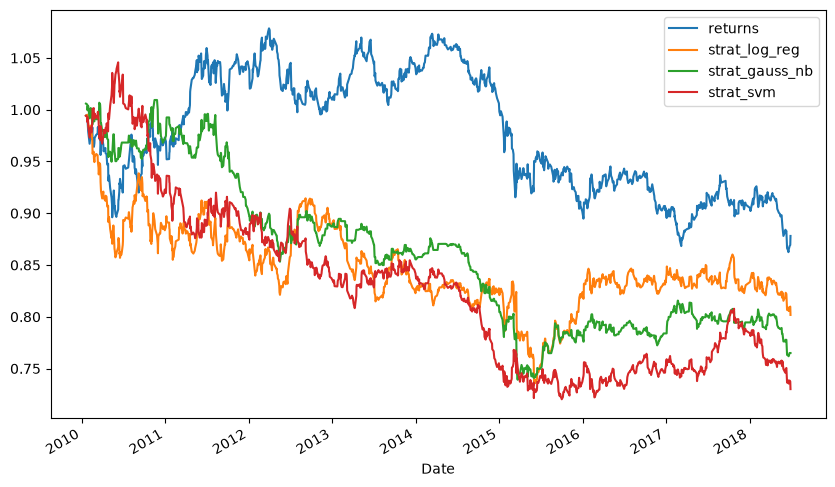

In [140]:
test[sel].cumsum().apply(np.exp).plot(figsize=(10, 6))

## 15.7 심층 신경망

### 15.7.1 scikit-learn을 사용한 심층 신경망

In [141]:
from sklearn.neural_network import MLPClassifier

In [142]:
model = MLPClassifier(solver='lbfgs', alpha=1e-5, hidden_layer_sizes=2 * [250], random_state=1)

In [143]:
%time model.fit(data[cols_bin], data['direction'])

CPU times: user 30.8 s, sys: 2.18 s, total: 33 s
Wall time: 1.87 s


/opt/homebrew/Caskroom/miniconda/base/envs/py4fi/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","[250, 250]"
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'lbfgs'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",1e-05
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",1
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [144]:
data['pos_dnn_sk'] = model.predict(data[cols_bin])

In [145]:
data['strat_dnn_sk'] = data['pos_dnn_sk'] * data['returns']

In [146]:
data[['returns', 'strat_dnn_sk']].sum().apply(np.exp)

returns          0.805002
strat_dnn_sk    42.849956
dtype: float64

<Axes: xlabel='Date'>

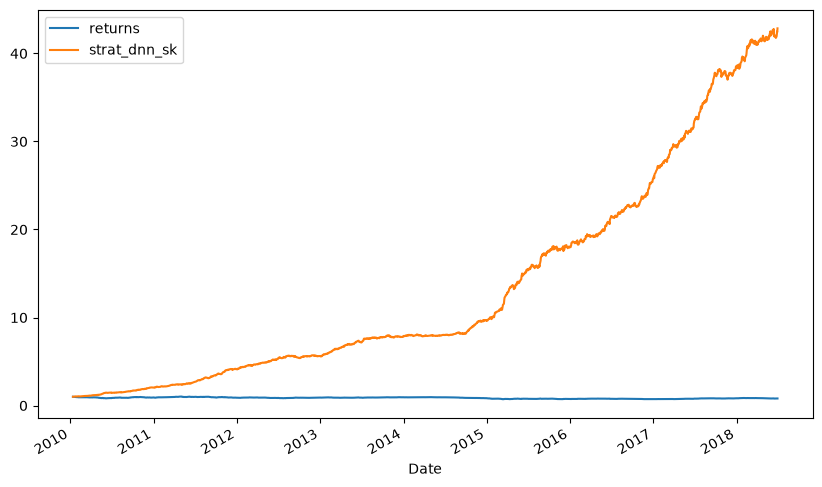

In [147]:
data[['returns', 'strat_dnn_sk']].cumsum().apply(np.exp).plot(figsize=(10, 6))

In [148]:
train, test = train_test_split(data, test_size=0.5, random_state=100)

In [149]:
train = train.copy().sort_index()

In [150]:
test = test.copy().sort_index()

In [151]:
model = MLPClassifier(solver='lbfgs', alpha=1e-5, max_iter=500, hidden_layer_sizes=3 * [500], random_state=1) # 은닉층의 개수와 은닉 유닛의 수를 증가

In [152]:
%time model.fit(train[cols_bin], train['direction'])

CPU times: user 4min 46s, sys: 33.9 s, total: 5min 20s
Wall time: 18.1 s


/opt/homebrew/Caskroom/miniconda/base/envs/py4fi/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","[500, 500, ...]"
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'lbfgs'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",1e-05
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",1
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [153]:
test['pos_dnn_sk'] = model.predict(test[cols_bin])

In [154]:
test['strat_dnn_sk'] = test['pos_dnn_sk'] * test['returns']

In [155]:
test[['returns', 'strat_dnn_sk']].sum().apply(np.exp)

returns         0.878078
strat_dnn_sk    0.989113
dtype: float64

<Axes: xlabel='Date'>

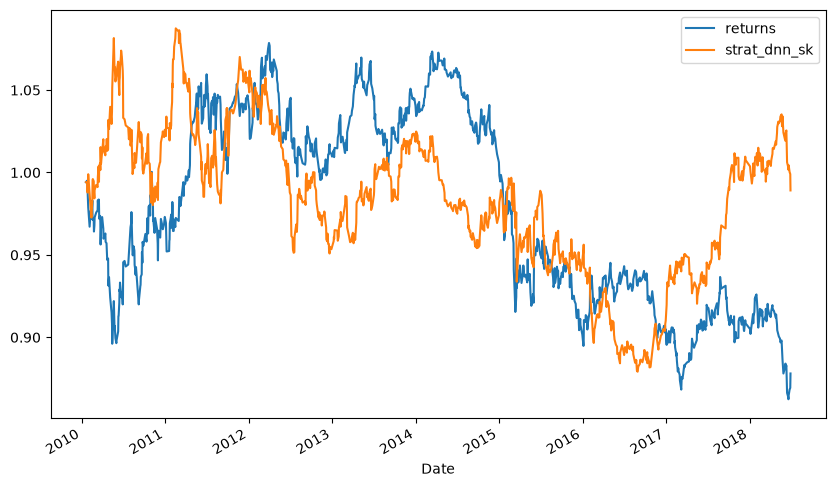

In [156]:
test[['returns', 'strat_dnn_sk']].cumsum().apply(np.exp).plot(figsize=(10, 6))

### 15.7.2 TensorFlow를 사용한 심층 신경망

In [157]:
import tensorflow as tf
from keras.layers import Dense
from keras.models import Sequential

In [158]:
def create_model():
    np.random.seed(100)
    tf.random.set_seed(100)

    model = Sequential()
    model.add(Dense(16, activation='relu', input_dim=lags))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

    return model

In [159]:
data_ = (data - data.mean()) / data.std()
data['direction_'] = np.where(data['direction'] == 1, 1, 0)

In [160]:
model = create_model()

/opt/homebrew/Caskroom/miniconda/base/envs/py4fi/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [161]:
%time model.fit(data_[cols], data['direction_'], epochs=50)

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 385us/step - accuracy: 0.5038 - loss: 0.7241 
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 302us/step - accuracy: 0.4986 - loss: 0.6987
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 275us/step - accuracy: 0.4958 - loss: 0.6947
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 266us/step - accuracy: 0.5094 - loss: 0.6931
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 268us/step - accuracy: 0.5117 - loss: 0.6921
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 272us/step - accuracy: 0.5188 - loss: 0.6913
Epoch 7/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 266us/step - accuracy: 0.5263 - loss: 0.6906
Epoch 8/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 267us/step - accuracy: 0.5281 - loss: 0.6899
Epoch 9/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 265us/step - accuracy: 0.5291 - loss: 0.6894
Epoch 10/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 271us/step - accuracy: 0.5291 - loss: 0.6889
Epoch 11/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 265us/step - accuracy: 0.5305 - loss: 0.6885
Epoch 12/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 266us/ste

In [162]:
model.evaluate(data_[cols], data['direction_'])

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 287us/step - accuracy: 0.5821 - loss: 0.6732


[0.6732422709465027, 0.5820825695991516]

In [163]:
pred = np.where(model.predict(data_[cols]) > 0.5, 1, 0)
pred[:10].flatten()

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 348us/step


array([0, 1, 0, 0, 0, 1, 1, 0, 1, 0])

In [164]:
data['pos_dnn_ke'] = np.where(pred > 0, 1, -1)

In [165]:
data['strat_dnn_ke'] = data['pos_dnn_ke'] * data['returns']

In [166]:
data[['returns', 'strat_dnn_ke']].sum().apply(np.exp)

returns         0.805002
strat_dnn_ke    5.830825
dtype: float64

<Axes: xlabel='Date'>

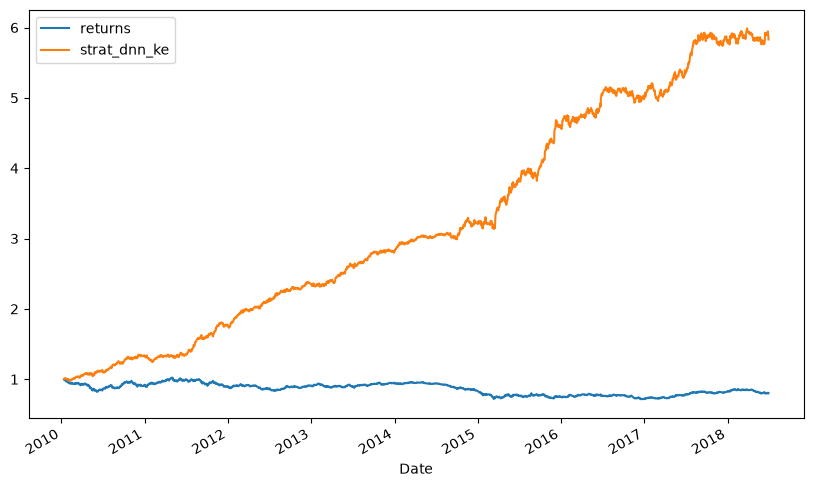

In [167]:
data[['returns', 'strat_dnn_ke']].cumsum().apply(np.exp).plot(figsize=(10, 6))

In [168]:
mu, std = train.mean(), train.std()

In [169]:
train_ = (train - mu) / std

In [170]:
model = create_model()

/opt/homebrew/Caskroom/miniconda/base/envs/py4fi/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [171]:
train['direction_'] = np.where(train['direction'] > 0, 1, 0)

In [172]:
%time model.fit(train_[cols], train['direction_'], epochs=50)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step - accuracy: 0.5141 - loss: 0.7051 
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - accuracy: 0.4972 - loss: 0.6966
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 397us/step - accuracy: 0.5019 - loss: 0.6934
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 345us/step - accuracy: 0.5178 - loss: 0.6912
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 339us/step - accuracy: 0.5300 - loss: 0.6897
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 331us/step - accuracy: 0.5310 - loss: 0.6884
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 339us/step - accuracy: 0.5394 - loss: 0.6873
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - accuracy: 0.5422 - loss: 0.6863
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 337us/step - accuracy: 0.5441 - loss: 0.6855
Epoch 10/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 532us/step - accuracy: 0.5563 - loss: 0.6849
Epoch 11/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step - accuracy: 0.5488 - loss: 0.6842
Epoch 12/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/ste

In [173]:
test_ = (test - mu) / std

In [174]:
test['direction_'] = np.where(test['direction'] > 0, 1, 0)

In [175]:
model.evaluate(test_[cols], test['direction_'])

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step - accuracy: 0.4841 - loss: 0.7126


[0.7126070857048035, 0.48405253887176514]

In [176]:
pred = np.where(model.predict(test_[cols]) > 0.5, 1, 0)
pred[:10].flatten()

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step


array([1, 1, 0, 0, 1, 1, 1, 1, 1, 1])

In [177]:
test['pos_dnn_ke'] = np.where(pred > 0, 1, -1)

In [178]:
test['strat_dnn_ke'] = test['pos_dnn_ke'] * test['returns']

In [179]:
test[['returns', 'strat_dnn_sk', 'strat_dnn_ke']].sum().apply(np.exp)

returns         0.878078
strat_dnn_sk    0.989113
strat_dnn_ke    0.797107
dtype: float64

<Axes: xlabel='Date'>

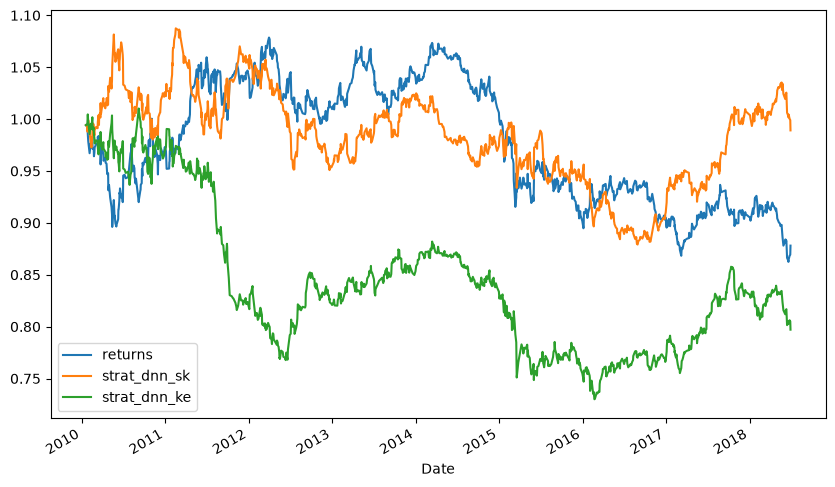

In [180]:
test[['returns', 'strat_dnn_sk', 'strat_dnn_ke']].cumsum().apply(np.exp).plot(figsize=(10, 6))